In [1]:
#Load Libraries
library(Seurat)
library(Signac)
library(GenomeInfoDb)
library(EnsDb.Hsapiens.v86)
library(BSgenome.Hsapiens.UCSC.hg38)
library(AnnotationHub)
library(GenomicRanges)
library(BiocParallel)
library(chromVAR)
library(TFBSTools)
library(cicero)
library(ggplot2)
library(patchwork)
library(reticulate)
library(sceasy)
library(future)
library(Matrix)
library(viridis)

#library(JASPAR2024)

#Set Options
options(future.globals.maxSize = 400000 * 1024^2) #for 300GB max size
plan("multicore", workers = 4)

register(SerialParam()) 
set.seed(1234)

#Set working directory
setwd("/storage1/fs1/jmillman/Active/DigitalTwin")

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, saveRDS


Loading Seurat v5 beta version 
To maintain compatibility with previous workflows, new Seurat objects will use the previous object structure by default
To use new Seurat v5 assays please run: options(Seurat.object.assay.version = 'v5')

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position,

In [2]:
install.packages("ggalluvial")
install.packages("ggplot2")
install.packages("dplyr")
install.packages("tidyr")

Installing package into '/storage1/fs1/jmillman/Active/Ed/R_libraries/Beagle Scouts.Beagle Scouts'
(as 'lib' is unspecified)

Installing package into '/storage1/fs1/jmillman/Active/Ed/R_libraries/Beagle Scouts.Beagle Scouts'
(as 'lib' is unspecified)

Installing package into '/storage1/fs1/jmillman/Active/Ed/R_libraries/Beagle Scouts.Beagle Scouts'
(as 'lib' is unspecified)

Installing package into '/storage1/fs1/jmillman/Active/Ed/R_libraries/Beagle Scouts.Beagle Scouts'
(as 'lib' is unspecified)



In [3]:
library(ggplot2)
library(ggalluvial)
library(scales)


Attaching package: 'scales'


The following object is masked from 'package:viridis':

    viridis_pal




In [4]:
#Fig. 2G

plot_stage_transition <- function(
  transition_name,
  folder = "outputs/cell_transition_matrices/selected_cell_states/",
  counts_file = "cellcounts.csv",
  pal,
  cell_order = names(pal),
  y_as_percent = FALSE,
  alpha = 0.9,
  stratum_width = 0.22,
  border_color = "black",
  label_size = 4,
  base_size = 13,
  show_title = TRUE,
  show_legend = FALSE,
  naked = FALSE,
  save_plot = FALSE,
  save_both = FALSE,
  save_table = FALSE,
  save_prefix = "alluvial",
  width = 7,
  height = 7,
  dpi = 300,
  table_width = 7,
  table_height = 4
) {
  library(ggplot2)
  library(ggalluvial)
  library(scales)
  library(gridExtra)
  library(grid)

  ### ---------------------------
  ### 1. Build file paths
  ### ---------------------------
  transition_file <- file.path(
    folder,
    paste0("transitions_", transition_name, "_subset.csv")
  )
  counts_path <- file.path(folder, counts_file)

  ### ---------------------------
  ### 2. Check files exist
  ### ---------------------------
  if (!dir.exists(folder)) {
    stop(paste0("Folder not found: ", folder))
  }

  if (!file.exists(transition_file)) {
    stop(paste0(
      "Transition file not found: ", transition_file,
      "\nExpected a file like: transitions_", transition_name, "_subset.csv"
    ))
  }

  if (!file.exists(counts_path)) {
    stop(paste0("Counts file not found: ", counts_path))
  }

  ### ---------------------------
  ### 3. Read counts table
  ### ---------------------------
  counts_df <- read.csv(counts_path, check.names = FALSE)
  counts_df <- counts_df[, !grepl("^Unnamed", colnames(counts_df)), drop = FALSE]

  required_count_cols <- c("stage", "celltype_labelled_by_protocol", "count")
  missing_count_cols <- setdiff(required_count_cols, colnames(counts_df))

  if (length(missing_count_cols) > 0) {
    stop(paste0(
      "The counts file is missing required columns: ",
      paste(missing_count_cols, collapse = ", ")
    ))
  }

  counts_df <- counts_df[, required_count_cols, drop = FALSE]

  ### ---------------------------
  ### 4. Read transition matrix
  ### ---------------------------
  trans_df <- read.csv(transition_file, check.names = FALSE)
  trans_df <- trans_df[, !grepl("^Unnamed:\\s*[3-9]|^Unnamed:\\s*[1-9][0-9]+", colnames(trans_df)), drop = FALSE]

  if (ncol(trans_df) < 2) {
    stop("Transition file does not look like a transition matrix.")
  }

  rownames(trans_df) <- trans_df[[1]]
  trans_df <- trans_df[, -1, drop = FALSE]

  trans_mat <- as.matrix(trans_df)
  mode(trans_mat) <- "numeric"

  ### ---------------------------
  ### 5. Extract stage numbers
  ### ---------------------------
  stage_nums <- regmatches(transition_name, gregexpr("[0-9]+", transition_name))[[1]]

  if (length(stage_nums) < 2) {
    stop(paste0(
      "Could not parse stage numbers from transition_name: ", transition_name,
      "\nUse something like 'Stage2_3'."
    ))
  }

  from_stage <- as.numeric(stage_nums[1])
  to_stage   <- as.numeric(stage_nums[2])

  ### ---------------------------
  ### 6. Get counts for source and target stage
  ### ---------------------------
  source_counts_df <- counts_df[counts_df$stage == from_stage, , drop = FALSE]
  target_counts_df <- counts_df[counts_df$stage == to_stage, , drop = FALSE]

  if (nrow(source_counts_df) == 0) {
    stop(paste0("No counts found in ", counts_file, " for stage ", from_stage))
  }
  if (nrow(target_counts_df) == 0) {
    stop(paste0("No counts found in ", counts_file, " for stage ", to_stage))
  }

  source_counts <- source_counts_df$count
  names(source_counts) <- source_counts_df$celltype_labelled_by_protocol

  ### ---------------------------
  ### 7. Harmonize states for plot
  ### ---------------------------
  common_sources <- intersect(names(source_counts), rownames(trans_mat))

  if (length(common_sources) == 0) {
    stop("No overlapping source cell types between counts file and transition matrix.")
  }

  source_counts_plot <- source_counts[common_sources]
  trans_mat_plot <- trans_mat[common_sources, , drop = FALSE]

  ### ---------------------------
  ### 8. Build flow table
  ### ---------------------------
  flow_list <- list()
  counter <- 1

  for (src in rownames(trans_mat_plot)) {
    for (dst in colnames(trans_mat_plot)) {
      flow_value <- source_counts_plot[src] * trans_mat_plot[src, dst]

      flow_list[[counter]] <- data.frame(
        source = src,
        target = dst,
        flow   = flow_value,
        stringsAsFactors = FALSE
      )

      counter <- counter + 1
    }
  }

  flow_df <- do.call(rbind, flow_list)

  ### ---------------------------
  ### 9. Optional proportions for plot y
  ### ---------------------------
  if (y_as_percent) {
    flow_df$y_value <- flow_df$flow / sum(flow_df$flow)
    y_scale <- scale_y_continuous(labels = percent_format(accuracy = 1))
    y_lab <- paste0("Proportion of Stage ", from_stage, " cells")
  } else {
    flow_df$y_value <- flow_df$flow
    y_scale <- scale_y_continuous(labels = comma_format())
    y_lab <- "Expected number of cells"
  }

  ### ---------------------------
  ### 10. Factor order
  ### ---------------------------
  present_states <- unique(c(flow_df$source, flow_df$target))
  ordered_levels <- cell_order[cell_order %in% present_states]
  unordered_leftovers <- setdiff(present_states, ordered_levels)
  final_levels <- c(ordered_levels, unordered_leftovers)

  flow_df$source <- factor(flow_df$source, levels = final_levels)
  flow_df$target <- factor(flow_df$target, levels = final_levels)

  ### ---------------------------
  ### 11. Build full plot
  ### ---------------------------
  p_full <- ggplot(
    flow_df,
    aes(axis1 = source, axis2 = target, y = y_value)
  ) +
    geom_alluvium(
      aes(fill = source),
      width = stratum_width,
      alpha = alpha,
      color = NA
    ) +
    geom_stratum(
      aes(fill = after_stat(stratum)),
      width = stratum_width,
      color = border_color
    ) +
    geom_text(
      stat = "stratum",
      aes(label = after_stat(stratum)),
      size = label_size
    ) +
    scale_fill_manual(values = pal, drop = FALSE) +
    scale_x_discrete(
      limits = c(paste("Stage", from_stage), paste("Stage", to_stage)),
      expand = c(0.08, 0.08)
    ) +
    y_scale +
    labs(
      x = NULL,
      y = y_lab,
      title = if (show_title) paste("Stage", from_stage, "to Stage", to_stage, "transitions") else NULL
    ) +
    theme_classic(base_size = base_size)

  if (!show_legend) {
    p_full <- p_full + theme(legend.position = "none")
  }

  ### ---------------------------
  ### 12. Build naked plot
  ### ---------------------------
  p_naked <- ggplot(
    flow_df,
    aes(axis1 = source, axis2 = target, y = y_value)
  ) +
    geom_alluvium(
      aes(fill = source),
      width = stratum_width,
      alpha = alpha,
      color = NA
    ) +
    geom_stratum(
      aes(fill = after_stat(stratum)),
      width = stratum_width,
      color = NA
    ) +
    scale_fill_manual(values = pal, drop = FALSE) +
    scale_x_discrete(
      limits = c(paste("Stage", from_stage), paste("Stage", to_stage)),
      expand = c(0.08, 0.08)
    ) +
    y_scale +
    labs(
      x = NULL,
      y = NULL,
      title = NULL
    ) +
    theme_void(base_size = base_size) +
    theme(
      legend.position = "none",
      plot.title = element_blank()
    )

  ### ---------------------------
  ### 13. Build table data from plotted cell types only
  ### ---------------------------
  source_states_for_plot <- rownames(trans_mat_plot)
  target_states_for_plot <- colnames(trans_mat_plot)

  source_table <- data.frame(
    CellType = source_counts_df$celltype_labelled_by_protocol,
    Count_from = source_counts_df$count,
    stringsAsFactors = FALSE
  )
  target_table <- data.frame(
    CellType = target_counts_df$celltype_labelled_by_protocol,
    Count_to = target_counts_df$count,
    stringsAsFactors = FALSE
  )

  source_table <- source_table[source_table$CellType %in% source_states_for_plot, , drop = FALSE]
  target_table <- target_table[target_table$CellType %in% target_states_for_plot, , drop = FALSE]

  all_states_for_plot <- unique(c(source_states_for_plot, target_states_for_plot))

  ordered_table_levels <- cell_order[cell_order %in% all_states_for_plot]
  unordered_table_leftovers <- setdiff(all_states_for_plot, ordered_table_levels)
  table_levels <- c(ordered_table_levels, unordered_table_leftovers)

  table_df <- merge(
    data.frame(CellType = table_levels, stringsAsFactors = FALSE),
    source_table,
    by = "CellType",
    all.x = TRUE
  )
  table_df <- merge(
    table_df,
    target_table,
    by = "CellType",
    all.x = TRUE
  )

  table_df$Count_from[is.na(table_df$Count_from)] <- 0
  table_df$Count_to[is.na(table_df$Count_to)] <- 0

  total_from <- sum(table_df$Count_from)
  total_to <- sum(table_df$Count_to)

  table_df$Percent_from <- if (total_from > 0) table_df$Count_from / total_from else 0
  table_df$Percent_to   <- if (total_to > 0) table_df$Count_to / total_to else 0

  table_display <- data.frame(
    CellType = table_df$CellType,
    Count_Stage_from = comma(table_df$Count_from),
    Percent_Stage_from = percent(table_df$Percent_from, accuracy = 0.1),
    Count_Stage_to = comma(table_df$Count_to),
    Percent_Stage_to = percent(table_df$Percent_to, accuracy = 0.1),
    stringsAsFactors = FALSE
  )

  colnames(table_display) <- c(
    "Cell type",
    paste0("Stage ", from_stage, " count"),
    paste0("Stage ", from_stage, " %"),
    paste0("Stage ", to_stage, " count"),
    paste0("Stage ", to_stage, " %")
  )

  ### ---------------------------
  ### 14. Choose which plot to return as $plot
  ### ---------------------------
  p_main <- if (naked) p_naked else p_full

  ### ---------------------------
  ### 15. Save plot(s) if requested
  ### ---------------------------
  saved_plot_file <- NULL
  saved_full_file <- NULL
  saved_naked_file <- NULL

  if (save_both) {
    saved_full_file <- file.path(
      folder,
      paste0(save_prefix, "_", transition_name, "_full.png")
    )
    saved_naked_file <- file.path(
      folder,
      paste0(save_prefix, "_", transition_name, "_naked.png")
    )

    ggsave(
      filename = saved_full_file,
      plot = p_full,
      width = width,
      height = height,
      dpi = dpi,
      units = "in",
      bg = "white"
    )

    ggsave(
      filename = saved_naked_file,
      plot = p_naked,
      width = width,
      height = height,
      dpi = dpi,
      units = "in",
      bg = "white"
    )
  } else if (save_plot) {
    suffix <- if (naked) "naked" else "full"
    saved_plot_file <- file.path(
      folder,
      paste0(save_prefix, "_", transition_name, "_", suffix, ".png")
    )

    ggsave(
      filename = saved_plot_file,
      plot = p_main,
      width = width,
      height = height,
      dpi = dpi,
      units = "in",
      bg = "white"
    )
  }

  ### ---------------------------
  ### 16. Save table PNG if requested
  ### ---------------------------
  saved_table_file <- NULL

  if (save_table) {
    table_file_name <- paste0(save_prefix, "_", transition_name, "_table.png")
    saved_table_file <- file.path(folder, table_file_name)

    tg <- tableGrob(
      table_display,
      rows = NULL,
      theme = ttheme_minimal(
        base_size = 12,
        core = list(fg_params = list(hjust = 0.5, x = 0.5)),
        colhead = list(fg_params = list(fontface = "bold"))
      )
    )

    png(
      filename = saved_table_file,
      width = table_width,
      height = table_height,
      units = "in",
      res = dpi,
      bg = "white"
    )
    grid.newpage()
    grid.draw(tg)
    dev.off()
  }

  return(list(
    plot = p_main,
    plot_full = p_full,
    plot_naked = p_naked,
    flow_df = flow_df,
    table_df = table_display,
    transition_file = transition_file,
    counts_file = counts_path,
    saved_plot_file = saved_plot_file,
    saved_full_file = saved_full_file,
    saved_naked_file = saved_naked_file,
    saved_table_file = saved_table_file
  ))
}

In [5]:
pal <- c(
  "Mesench." = "#ffbd00",
  "Prolif."  = "#CC6677",
  "DE"       = "#a7defa",
  "GT"       = "#DDCC77",
  "PP"       = "#402bad",
  "Exo"      = "#117733",
  "UE"       = "#EE3377",
  "eEP"      = "#fcb686",
  "lEP"      = "#cd853f",
  "SIC"       = "#015f94",
  "Beta-SIC"  = "#AA4499",
  "Beta"     = "#ba0c2f",
  "Delta"    = "#7d9e31",
  "Alpha"    = "#f55e07"
)

In [6]:
res <- plot_stage_transition(
  "Stage1_2",
  folder = "outputs/cell_transition_matrices/selected_cell_states",
  pal = pal,
  save_both = TRUE,
  save_table = TRUE
)


Attaching package: 'gridExtra'


The following object is masked from 'package:Biobase':

    combine


The following object is masked from 'package:BiocGenerics':

    combine


Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."


In [10]:
res <- plot_stage_transition(
  "Stage2_3",
  folder = "outputs/cell_transition_matrices/selected_cell_states",
  pal = pal,
  save_both = TRUE,
  save_table = TRUE
)

Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."


In [11]:
res <- plot_stage_transition(
  "Stage3_4",
  folder = "outputs/cell_transition_matrices/selected_cell_states",
  pal = pal,
  save_both = TRUE,
  save_table = TRUE
)

Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."


In [12]:
res <- plot_stage_transition(
  "Stage4_5",
  folder = "outputs/cell_transition_matrices/selected_cell_states",
  pal = pal,
  save_both = TRUE,
  save_table = TRUE
)

Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."


In [13]:
res <- plot_stage_transition(
  "Stage5_6",
  folder = "outputs/cell_transition_matrices/selected_cell_states",
  pal = pal,
  save_both = TRUE,
  save_table = TRUE
)

Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."


Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."


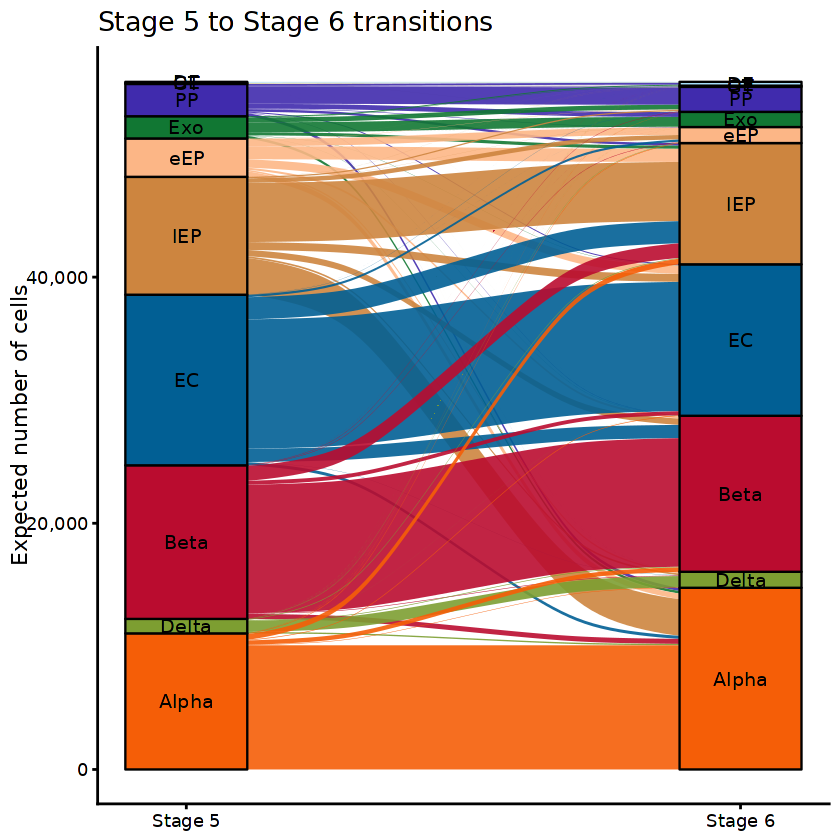

Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."


$plot

$plot_full

$plot_naked

$flow_df
       source target         flow      y_value
DE         DE     DE 6.312398e+01 6.312398e+01
DE1        DE     GT 2.763328e+00 2.763328e+00
DE2        DE     PP 1.058166e+01 1.058166e+01
DE3        DE    Exo 4.035044e+00 4.035044e+00
DE4        DE    eEP 4.554797e-01 4.554797e-01
DE5        DE    lEP 2.210986e+00 2.210986e+00
DE6        DE  Alpha 1.206476e-01 1.206476e-01
DE7        DE  Delta 5.693364e-01 5.693364e-01
DE8        DE     EC 6.231958e-01 6.231958e-01
DE9        DE   Beta 2.516340e+00 2.516340e+00
GT         GT     DE 1.937473e+01 1.937473e+01
GT1        GT     GT 1.386073e+01 1.386073e+01
GT2        GT     PP 2.504280e+01 2.504280e+01
GT3        GT    Exo 1.541963e+01 1.541963e+01
GT4        GT    eEP 4.540864e-02 4.540864e-02
GT5        GT    lEP 4.193139e+00 4.193139e+00
GT6        GT  Alpha 2.476892e+00 2.476892e+00
GT7        GT  Delta 1.986444e-21 1.986444e-21
GT8        GT     EC 3.019454e+00 3.019454e+00
GT9        GT   Bet

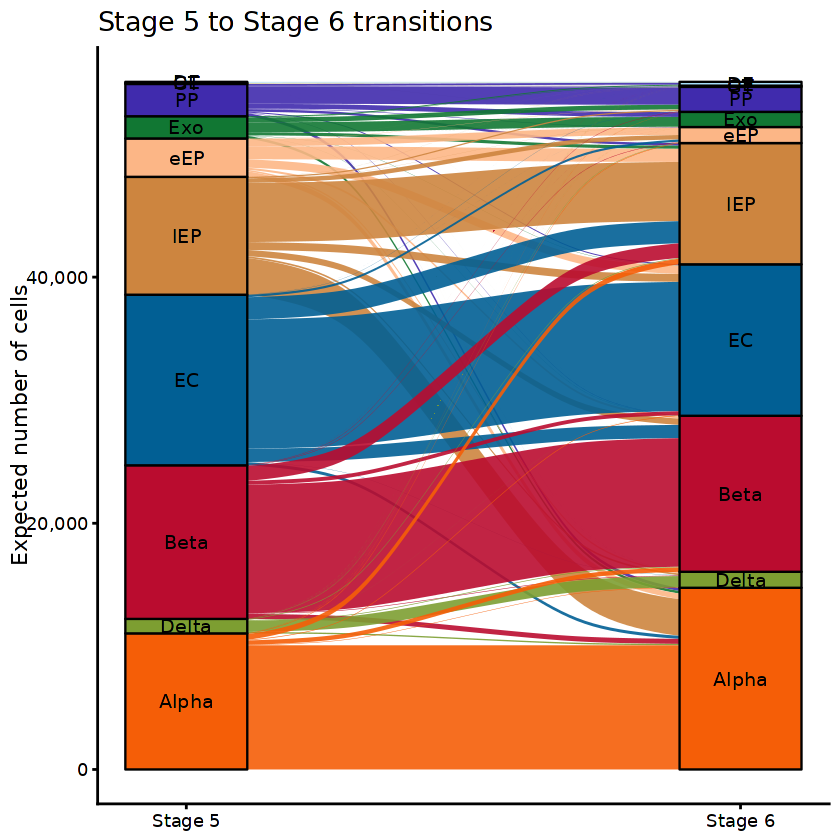

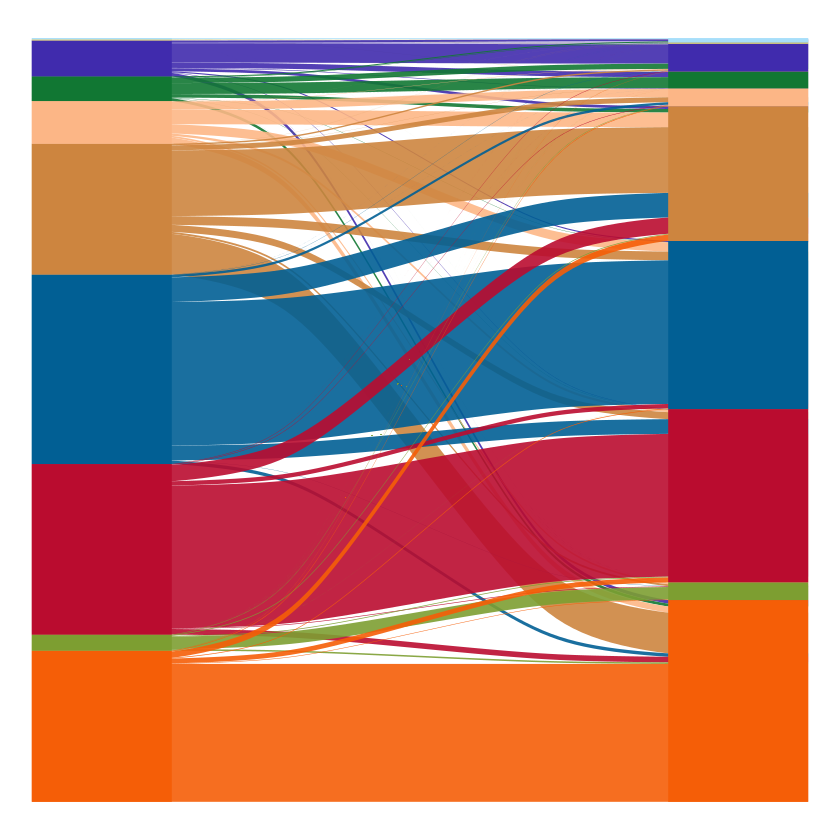

In [14]:
res #Fig. 2G

In [7]:
res <- plot_stage_transition(
  "Stage6_6",
  folder = "outputs/cell_transition_matrices/selected_cell_states",
  pal = pal,
  save_both = TRUE,
  save_table = TRUE
)


Attaching package: 'gridExtra'


The following object is masked from 'package:Biobase':

    combine


The following object is masked from 'package:BiocGenerics':

    combine


Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
"Some strata appear at multiple axes."


In [10]:
library(scales)

calculate_transition_rmse <- function(
  transition_names = c("Stage1_2", "Stage2_3", "Stage3_4", "Stage4_5", "Stage5_6"),
  folder = "outputs/cell_transition_matrices/selected_cell_states/",
  counts_file = "cellcounts.csv"
) {
  
  ### ---------------------------
  ### 1. Read counts table
  ### ---------------------------
  counts_path <- file.path(folder, counts_file)
  
  if (!file.exists(counts_path)) {
    stop(paste0("Counts file not found: ", counts_path))
  }
  
  counts_df <- read.csv(counts_path, check.names = FALSE)
  counts_df <- counts_df[, !grepl("^Unnamed", colnames(counts_df)), drop = FALSE]
  
  required_count_cols <- c("stage", "celltype_labelled_by_protocol", "count")
  missing_count_cols <- setdiff(required_count_cols, colnames(counts_df))
  
  if (length(missing_count_cols) > 0) {
    stop(paste0(
      "The counts file is missing required columns: ",
      paste(missing_count_cols, collapse = ", ")
    ))
  }
  
  counts_df <- counts_df[, required_count_cols, drop = FALSE]
  
  ### ---------------------------
  ### 2. Helper RMSE function
  ### ---------------------------
  rmse_fun <- function(pred, obs) {
    sqrt(mean((pred - obs)^2))
  }
  
  ### ---------------------------
  ### 3. Loop through transitions
  ### ---------------------------
  results_list <- list()
  
  for (i in seq_along(transition_names)) {
    
    transition_name <- transition_names[i]
    transition_file <- file.path(
      folder,
      paste0("transitions_", transition_name, "_subset.csv")
    )
    
    if (!file.exists(transition_file)) {
      warning(paste0("Transition file not found, skipping: ", transition_file))
      next
    }
    
    ### Parse stage numbers
    stage_nums <- regmatches(transition_name, gregexpr("[0-9]+", transition_name))[[1]]
    
    if (length(stage_nums) < 2) {
      warning(paste0("Could not parse stage numbers for: ", transition_name))
      next
    }
    
    from_stage <- as.numeric(stage_nums[1])
    to_stage   <- as.numeric(stage_nums[2])
    
    ### ---------------------------
    ### 4. Read transition matrix
    ### ---------------------------
    trans_df <- read.csv(transition_file, check.names = FALSE)
    trans_df <- trans_df[, !grepl("^Unnamed:\\s*[3-9]|^Unnamed:\\s*[1-9][0-9]+", colnames(trans_df)), drop = FALSE]
    
    if (ncol(trans_df) < 2) {
      warning(paste0("Transition file malformed, skipping: ", transition_file))
      next
    }
    
    rownames(trans_df) <- trans_df[[1]]
    trans_df <- trans_df[, -1, drop = FALSE]
    
    trans_mat <- as.matrix(trans_df)
    mode(trans_mat) <- "numeric"
    
    source_states <- rownames(trans_mat)
    target_states <- colnames(trans_mat)
    
    ### ---------------------------
    ### 5. Get real source counts
    ### ---------------------------
    source_counts_df <- counts_df[counts_df$stage == from_stage, , drop = FALSE]
    target_counts_df <- counts_df[counts_df$stage == to_stage, , drop = FALSE]
    
    if (nrow(source_counts_df) == 0) {
      warning(paste0("No counts found for source stage ", from_stage, "; skipping ", transition_name))
      next
    }
    if (nrow(target_counts_df) == 0) {
      warning(paste0("No counts found for target stage ", to_stage, "; skipping ", transition_name))
      next
    }
    
    source_counts <- source_counts_df$count
    names(source_counts) <- source_counts_df$celltype_labelled_by_protocol
    
    target_counts <- target_counts_df$count
    names(target_counts) <- target_counts_df$celltype_labelled_by_protocol
    
    ### Keep only states used in this transition
    source_counts <- source_counts[source_states]
    target_counts <- target_counts[target_states]
    
    source_counts[is.na(source_counts)] <- 0
    target_counts[is.na(target_counts)] <- 0
    
    ### ---------------------------
    ### 6. Convert to proportions
    ### Source proportions are normalized only within plotted source states
    ### Target proportions are normalized only within plotted target states
    ### ---------------------------
    source_props <- source_counts / sum(source_counts)
    observed_target_props <- target_counts / sum(target_counts)
    
    ### ---------------------------
    ### 7. Predict target proportions
    ### source_props is a row vector
    ### predicted_target_props = source_props %*% trans_mat
    ### ---------------------------
    predicted_target_props <- as.numeric(source_props %*% trans_mat)
    names(predicted_target_props) <- target_states
    
    ### ---------------------------
    ### 8. Compute RMSE
    ### ---------------------------
    this_rmse <- rmse_fun(predicted_target_props, observed_target_props)
    
    ### Optional diagnostics
    comparison_df <- data.frame(
      transition = transition_name,
      target_state = target_states,
      predicted_prop = predicted_target_props,
      observed_prop = observed_target_props,
      abs_error = abs(predicted_target_props - observed_target_props),
      stringsAsFactors = FALSE
    )
    
    results_list[[length(results_list) + 1]] <- list(
      summary = data.frame(
        transition = transition_name,
        from_stage = from_stage,
        to_stage = to_stage,
        n_target_states = length(target_states),
        rmse = this_rmse,
        stringsAsFactors = FALSE
      ),
      comparison = comparison_df
    )
  }
  
  if (length(results_list) == 0) {
    stop("No valid transitions were processed.")
  }
  
  ### ---------------------------
  ### 9. Combine outputs
  ### ---------------------------
  rmse_summary <- do.call(
    rbind,
    lapply(results_list, function(x) x$summary)
  )
  
  rmse_comparison <- do.call(
    rbind,
    lapply(results_list, function(x) x$comparison)
  )
  
  return(list(
    rmse_summary = rmse_summary,
    rmse_comparison = rmse_comparison
  ))
}

In [11]:
rmse_res <- calculate_transition_rmse(
  transition_names = c("Stage1_2", "Stage2_3", "Stage3_4", "Stage4_5", "Stage5_6"),
  folder = "outputs/cell_transition_matrices/selected_cell_states",
  counts_file = "cellcounts.csv"
)

In [12]:
rmse_res$rmse_summary

transition,from_stage,to_stage,n_target_states,rmse
<chr>,<dbl>,<dbl>,<int>,<dbl>
Stage1_2,1,2,7,0.007223236
Stage2_3,2,3,10,0.006179755
Stage3_4,3,4,10,0.035080121
Stage4_5,4,5,10,0.038686183
Stage5_6,5,6,10,0.020145354


In [13]:
rmse_res$rmse_comparison

,transition,target_state,predicted_prop,observed_prop,abs_error
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
DE,Stage1_2,DE,0.1898220854,0.1733356133,1.648647e-02
GT,Stage1_2,GT,0.5793672514,0.5825353397,3.168088e-03
PP,Stage1_2,PP,0.1326765041,0.1390218878,6.345384e-03
Exo,Stage1_2,Exo,0.0970073420,0.1035681715,6.560829e-03
eEP,Stage1_2,eEP,0.0002982842,0.0003419973,4.371311e-05
lEP,Stage1_2,lEP,0.0000471558,0.0001709986,1.238428e-04
Alpha,Stage1_2,Alpha,0.0007813771,0.0010259918,2.446147e-04
DE1,Stage2_3,DE,0.0165770974,0.0170726541,4.955567e-04
GT1,Stage2_3,GT,0.0460589952,0.0520440585,5.985063e-03


In [20]:
library(scales)

calculate_cellstate_rmse <- function(
  transition_names = c("Stage1_2", "Stage2_3", "Stage3_4", "Stage4_5", "Stage5_6"),
  folder = "outputs/cell_transition_matrices/selected_cell_states",
  counts_file = "cellcounts.csv"
) {
  
  ### ---------------------------
  ### 1. Read counts table
  ### ---------------------------
  counts_path <- file.path(folder, counts_file)
  
  if (!file.exists(counts_path)) {
    stop(paste0("Counts file not found: ", counts_path))
  }
  
  counts_df <- read.csv(counts_path, check.names = FALSE)
  counts_df <- counts_df[, !grepl("^Unnamed", colnames(counts_df)), drop = FALSE]
  
  required_count_cols <- c("stage", "celltype_labelled_by_protocol", "count")
  missing_count_cols <- setdiff(required_count_cols, colnames(counts_df))
  
  if (length(missing_count_cols) > 0) {
    stop(paste0(
      "The counts file is missing required columns: ",
      paste(missing_count_cols, collapse = ", ")
    ))
  }
  
  counts_df <- counts_df[, required_count_cols, drop = FALSE]
  
  ### ---------------------------
  ### 2. Helper RMSE function
  ### ---------------------------
  rmse_fun <- function(pred, obs) {
    sqrt(mean((pred - obs)^2))
  }
  
  ### ---------------------------
  ### 3. Collect predicted vs observed per cell state
  ### ---------------------------
  all_comparisons <- list()
  
  for (i in seq_along(transition_names)) {
    
    transition_name <- transition_names[i]
    transition_file <- file.path(
      folder,
      paste0("transitions_", transition_name, "_subset.csv")
    )
    
    if (!file.exists(transition_file)) {
      warning(paste0("Transition file not found, skipping: ", transition_file))
      next
    }
    
    ### Parse stage numbers
    stage_nums <- regmatches(transition_name, gregexpr("[0-9]+", transition_name))[[1]]
    
    if (length(stage_nums) < 2) {
      warning(paste0("Could not parse stage numbers for: ", transition_name))
      next
    }
    
    from_stage <- as.numeric(stage_nums[1])
    to_stage   <- as.numeric(stage_nums[2])
    
    ### ---------------------------
    ### 4. Read transition matrix
    ### ---------------------------
    trans_df <- read.csv(transition_file, check.names = FALSE)
    trans_df <- trans_df[, !grepl("^Unnamed:\\s*[3-9]|^Unnamed:\\s*[1-9][0-9]+", colnames(trans_df)), drop = FALSE]
    
    if (ncol(trans_df) < 2) {
      warning(paste0("Transition file malformed, skipping: ", transition_file))
      next
    }
    
    rownames(trans_df) <- trans_df[[1]]
    trans_df <- trans_df[, -1, drop = FALSE]
    
    trans_mat <- as.matrix(trans_df)
    mode(trans_mat) <- "numeric"
    
    source_states <- rownames(trans_mat)
    target_states <- colnames(trans_mat)
    
    ### ---------------------------
    ### 5. Get real counts for source and target
    ### ---------------------------
    source_counts_df <- counts_df[counts_df$stage == from_stage, , drop = FALSE]
    target_counts_df <- counts_df[counts_df$stage == to_stage, , drop = FALSE]
    
    if (nrow(source_counts_df) == 0) {
      warning(paste0("No counts found for source stage ", from_stage, "; skipping ", transition_name))
      next
    }
    if (nrow(target_counts_df) == 0) {
      warning(paste0("No counts found for target stage ", to_stage, "; skipping ", transition_name))
      next
    }
    
    source_counts <- source_counts_df$count
    names(source_counts) <- source_counts_df$celltype_labelled_by_protocol
    
    target_counts <- target_counts_df$count
    names(target_counts) <- target_counts_df$celltype_labelled_by_protocol
    
    source_counts <- source_counts[source_states]
    target_counts <- target_counts[target_states]
    
    source_counts[is.na(source_counts)] <- 0
    target_counts[is.na(target_counts)] <- 0
    
    ### ---------------------------
    ### 6. Convert to proportions
    ### ---------------------------
    source_props <- source_counts / sum(source_counts)
    observed_target_props <- target_counts / sum(target_counts)
    
    ### ---------------------------
    ### 7. Predict target proportions
    ### ---------------------------
    predicted_target_props <- as.numeric(source_props %*% trans_mat)
    names(predicted_target_props) <- target_states
    
    ### ---------------------------
    ### 8. Store per-cell-state comparison
    ### ---------------------------
    comparison_df <- data.frame(
      cell_state = target_states,
      transition = transition_name,
      from_stage = from_stage,
      to_stage = to_stage,
      predicted_prop = predicted_target_props,
      observed_prop = observed_target_props,
      sq_error = (predicted_target_props - observed_target_props)^2,
      abs_error = abs(predicted_target_props - observed_target_props),
      stringsAsFactors = FALSE
    )
    
    all_comparisons[[length(all_comparisons) + 1]] <- comparison_df
  }
  
  if (length(all_comparisons) == 0) {
    stop("No valid transitions were processed.")
  }
  
  comparison_all <- do.call(rbind, all_comparisons)
  
  ### ---------------------------
  ### 9. Compute RMSE per cell state
  ### ---------------------------
  split_by_state <- split(comparison_all, comparison_all$cell_state)
  
  rmse_by_state <- lapply(split_by_state, function(df) {
    data.frame(
      cell_state = unique(df$cell_state),
      n_transitions = nrow(df),
      rmse = sqrt(mean(df$sq_error)),
      mean_abs_error = mean(df$abs_error),
      mean_predicted_prop = mean(df$predicted_prop),
      mean_observed_prop = mean(df$observed_prop),
      stringsAsFactors = FALSE
    )
  })
  
  rmse_by_state <- do.call(rbind, rmse_by_state)
  rownames(rmse_by_state) <- NULL
  
  ### Ordering
  rmse_by_state <- rmse_by_state[order(rmse_by_state$rmse, decreasing = TRUE), ]
  
  return(list(
    rmse_by_state = rmse_by_state,
    comparison_all = comparison_all
  ))
}

In [21]:
cellstate_res <- calculate_cellstate_rmse(
  transition_names = c("Stage1_2", "Stage2_3", "Stage3_4", "Stage4_5", "Stage5_6"),
  folder = "outputs/cell_transition_matrices/selected_cell_states",
  counts_file = "cellcounts.csv"
)

In [22]:
cellstate_res$rmse_by_state

,cell_state,n_transitions,rmse,mean_abs_error,mean_predicted_prop,mean_observed_prop
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
10,PP,5,0.039923087,0.031609992,0.17695871,0.14788687
2,Beta,4,0.038957621,0.026951736,0.10602036,0.12545267
7,Exo,5,0.038882221,0.029789607,0.11015428,0.08298901
1,Alpha,5,0.038017750,0.030381792,0.12405036,0.15443215
5,EC,4,0.020012700,0.015478766,0.15003399,0.16340528
6,eEP,5,0.013808404,0.009970254,0.10067279,0.10086946
9,lEP,5,0.008007937,0.006204345,0.09681370,0.09867717
3,DE,5,0.007665349,0.004839204,0.04563888,0.04099790
8,GT,5,0.003312927,0.002645973,0.12730080,0.12831608


In [23]:
cellstate_res$comparison_all

,cell_state,transition,from_stage,to_stage,predicted_prop,observed_prop,sq_error,abs_error
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DE,DE,Stage1_2,1,2,0.1898220854,0.1733356133,2.718038e-04,1.648647e-02
GT,GT,Stage1_2,1,2,0.5793672514,0.5825353397,1.003678e-05,3.168088e-03
PP,PP,Stage1_2,1,2,0.1326765041,0.1390218878,4.026389e-05,6.345384e-03
Exo,Exo,Stage1_2,1,2,0.0970073420,0.1035681715,4.304448e-05,6.560829e-03
eEP,eEP,Stage1_2,1,2,0.0002982842,0.0003419973,1.910836e-09,4.371311e-05
lEP,lEP,Stage1_2,1,2,0.0000471558,0.0001709986,1.533705e-08,1.238428e-04
Alpha,Alpha,Stage1_2,1,2,0.0007813771,0.0010259918,5.983637e-08,2.446147e-04
DE1,DE,Stage2_3,2,3,0.0165770974,0.0170726541,2.455765e-07,4.955567e-04
GT1,GT,Stage2_3,2,3,0.0460589952,0.0520440585,3.582098e-05,5.985063e-03


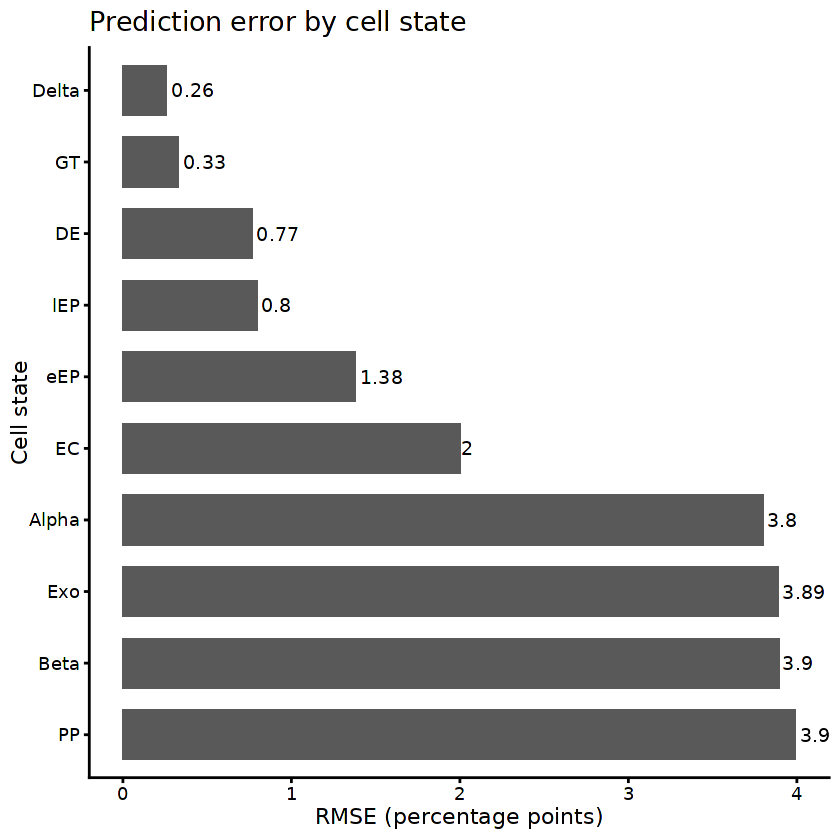

In [26]:
library(ggplot2)

rmse_cell_df <- cellstate_res$rmse_by_state
rmse_cell_df$rmse_pct_points <- rmse_cell_df$rmse * 100

rmse_cell_df$cell_state <- factor(
  rmse_cell_df$cell_state,
  levels = rmse_cell_df$cell_state[order(rmse_cell_df$rmse_pct_points, decreasing = TRUE)]
)

ggplot(rmse_cell_df, aes(x = cell_state, y = rmse_pct_points)) +
  geom_col(width = 0.7) +
  geom_text(
    aes(label = round(rmse_pct_points, 2)),
    hjust = -0.1,
    size = 4
  ) +
  coord_flip() +
  labs(
    x = "Cell state",
    y = "RMSE (percentage points)",
    title = "Prediction error by cell state"
  ) +
  theme_classic(base_size = 13)

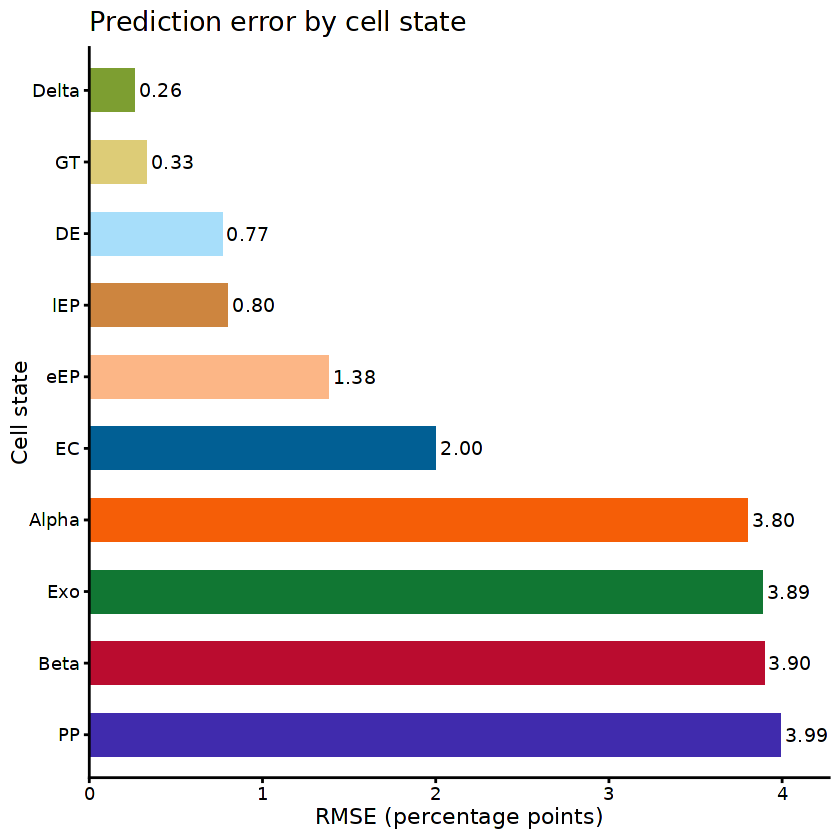

In [57]:
ggplot(rmse_cell_df, aes(x = cell_state, y = rmse_pct_points, fill = cell_state)) +
  geom_col(width = 0.6) +
  geom_text(
    aes(label = sprintf("%.2f", rmse_pct_points)),
    hjust = -0.1,
    size = 4
  ) +
  coord_flip() +
  scale_fill_manual(values = pal, drop = FALSE) +
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.07))
  ) +
  labs(
    x = "Cell state",
    y = "RMSE (percentage points)",
    title = "Prediction error by cell state"
  ) +
  theme_classic(base_size = 13) +
  theme(legend.position = "none")

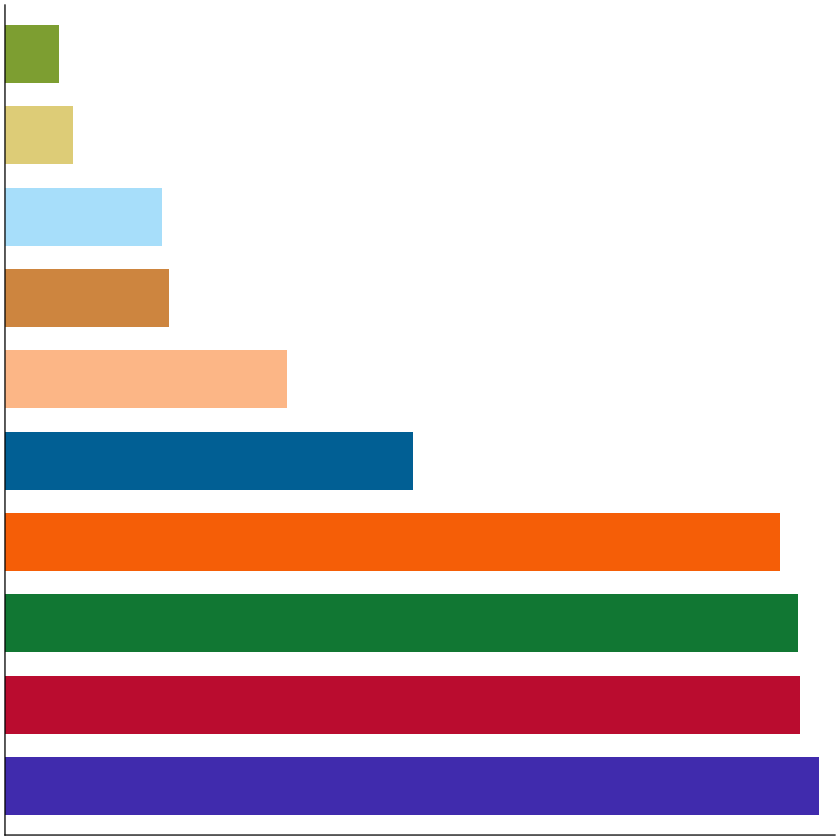

In [61]:
p_cell_rmse_tall <- ggplot(rmse_cell_df, aes(x = cell_state, y = rmse_pct_points, fill = cell_state)) +
  geom_col(width = 0.7) +
  coord_flip() +
  scale_fill_manual(values = pal, drop = FALSE) +
  scale_y_continuous(
    limits = c(0, max(4, max(rmse_cell_df$rmse_pct_points) * 1.02)),
    expand = expansion(mult = c(0, 0))
  ) +
  labs(
    x = NULL,
    y = NULL,
    title = NULL
  ) +
  theme_classic(base_size = 6) +
  theme(
    legend.position = "none",
    axis.title = element_blank(),
    axis.text = element_blank(),
    axis.ticks = element_blank()
  )

p_cell_rmse_tall

In [62]:
ggsave(
  "outputs/cell_transition_matrices/selected_cell_states/RMSE_by_cellstate_tall.png",
  plot = p_cell_rmse_tall,
  width = 1,
  height = 5,
  units = "cm",
  dpi = 300
)

In [ ]:
#Do you ever wonder? No, you girls never know. How you make a boy feel - No You Girls by Franz Ferdinand